<a href="https://colab.research.google.com/github/IT24100378/ToxicCommentNLPfinal/blob/Remove-punctuation-and-special-characters/Removing_Punctuations_and_Special_Characters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the dataset
file_path = "/content/train_preprocessed_lowercased.csv"  # update path if needed
df = pd.read_csv(file_path)

# Display first five rows
df.head()


,id,comment_text,toxic
0,0000997932d777bf,explanation\nwhy the edits made under my usern...,0
1,000103f0d9cfb60f,d'aww! he matches this background colour i'm s...,0
2,000113f07ec002fd,"hey man, i'm really not trying to edit war. it...",0
3,0001b41b1c6bb37e,"""\nmore\ni can't make any real suggestions on ...",0
4,0001d958c54c6e35,"you, sir, are my hero. any chance you remember...",0


Shape of dataset: (159571, 3)

Missing values:
 id              0
comment_text    0
toxic           0
dtype: int64

Class distribution:
 toxic
0    144278
1     15293
Name: count, dtype: int64


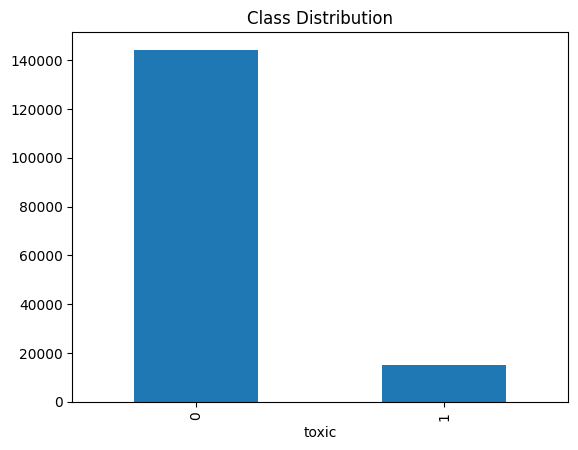

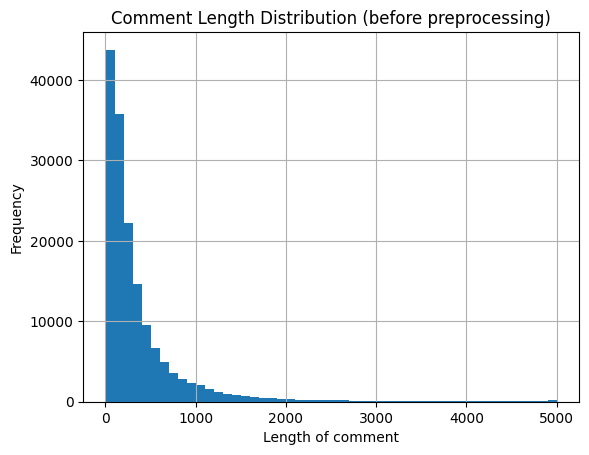

,comment_text,toxic
0,explanation\nwhy the edits made under my usern...,0
1,d'aww! he matches this background colour i'm s...,0
2,"hey man, i'm really not trying to edit war. it...",0
3,"""\nmore\ni can't make any real suggestions on ...",0
4,"you, sir, are my hero. any chance you remember...",0


In [2]:
#EDA BEFORE PREPROCESSING
import matplotlib.pyplot as plt

# Shape of dataset
print("Shape of dataset:", df.shape)

# Check null values
print("\nMissing values:\n", df.isnull().sum())

# Class distribution
print("\nClass distribution:\n", df['toxic'].value_counts())

df['toxic'].value_counts().plot(kind='bar', title='Class Distribution')
plt.show()

# Comment length analysis
df['comment_length'] = df['comment_text'].astype(str).apply(len)
df['comment_length'].hist(bins=50)
plt.title("Comment Length Distribution (before preprocessing)")
plt.xlabel("Length of comment")
plt.ylabel("Frequency")
plt.show()

# Display some examples
df[['comment_text', 'toxic']].head()


In [3]:
#Preprocessing remove punctuations and special characters
import re

def clean_text(text):
    # Remove punctuation & special characters, keep only letters/numbers/spaces
    text = re.sub(r'[^a-zA-Z0-9\s]', '', str(text))
    return text

# Apply cleaning
df['cleaned_comment'] = df['comment_text'].apply(clean_text)

# Show examples before vs after
df[['comment_text', 'cleaned_comment']].head()


,comment_text,cleaned_comment
0,explanation\nwhy the edits made under my usern...,explanation\nwhy the edits made under my usern...
1,d'aww! he matches this background colour i'm s...,daww he matches this background colour im seem...
2,"hey man, i'm really not trying to edit war. it...",hey man im really not trying to edit war its j...
3,"""\nmore\ni can't make any real suggestions on ...",\nmore\ni cant make any real suggestions on im...
4,"you, sir, are my hero. any chance you remember...",you sir are my hero any chance you remember wh...


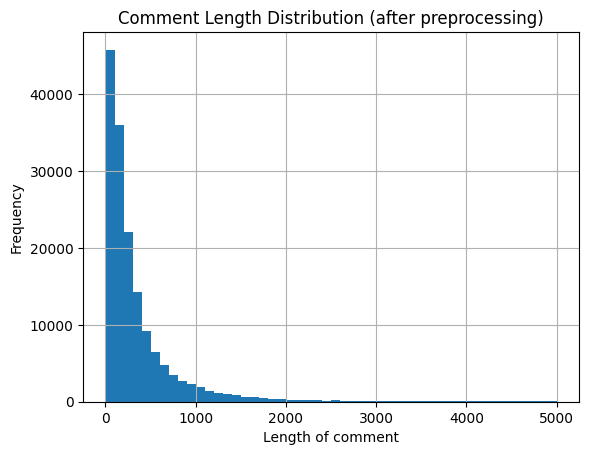

,cleaned_comment,toxic
0,explanation\nwhy the edits made under my usern...,0
1,daww he matches this background colour im seem...,0
2,hey man im really not trying to edit war its j...,0
3,\nmore\ni cant make any real suggestions on im...,0
4,you sir are my hero any chance you remember wh...,0


In [4]:
#EDA AFTER PREPROCESSING
# Comment length distribution after cleaning
df['cleaned_length'] = df['cleaned_comment'].astype(str).apply(len)
df['cleaned_length'].hist(bins=50)
plt.title("Comment Length Distribution (after preprocessing)")
plt.xlabel("Length of comment")
plt.ylabel("Frequency")
plt.show()

# Display first few cleaned comments
df[['cleaned_comment', 'toxic']].head()


In [6]:
# Keep only required columns
final_df = df[['id', 'cleaned_comment', 'toxic']]

# Save preprocessed dataset in Google Colab
output_path = "/content/train_preprocessed_cleaned.csv"
final_df.to_csv(output_path, index=False)
print("Preprocessed file saved at:", output_path)

# (Optional) Download to local machine
from google.colab import files
files.download(output_path)


Preprocessed file saved at: /content/train_preprocessed_cleaned.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>